<a href="https://colab.research.google.com/github/sumyuck/ML-learning/blob/main/ml/ML_p_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical - 7
Implement Support Vector Classification and Regression with Grid Search for Hyper-parameter tuning using sklearn. Plot the hyperplane. (3D plot)

1. SVM soft margin (linear dataset and simple data)
2. Non linear dataset
3. Multiple features dataset
4. SVR

In [ ]:
# Part 1: SVM (Soft-Margin, Linear) – 3D Hyperplane on Breast Cancer
# Part 2: SVM (Non-Linear RBF) – 2D Decision Regions on Iris (binary subset)
# Part 3: SVM (Multi-Feature, 3-class) – Wine dataset
# Part 4: SVR (Regression) – California Housing, 3D Surface

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    ConfusionMatrixDisplay
)


# ----- Helper plot functions -----
def plot_linear_svm_3d(X, y, svc_lin, feature_names, title):
    scaler = svc_lin.named_steps["scaler"]
    model = svc_lin.named_steps["svc"]

    Xs = scaler.transform(X)
    w = model.coef_[0]
    b = model.intercept_[0]

    xlim = (Xs[:, 0].min() - 1, Xs[:, 0].max() + 1)
    ylim = (Xs[:, 1].min() - 1, Xs[:, 1].max() + 1)
    xx, yy = np.meshgrid(np.linspace(*xlim, 25), np.linspace(*ylim, 25))

    def z_from_plane(k):
        w3 = w[2] if abs(w[2]) > 1e-12 else 1e-12
        return (-b - w[0] * xx - w[1] * yy + k) / w3

    zz0 = z_from_plane(0)
    zzp = z_from_plane(1)
    zzn = z_from_plane(-1)

    def inv_transform(xxg, yyg, zzg):
        grid = np.c_[xxg.ravel(), yyg.ravel(), zzg.ravel()]
        back = scaler.inverse_transform(grid)
        return (
            back[:, 0].reshape(xxg.shape),
            back[:, 1].reshape(yyg.shape),
            back[:, 2].reshape(zzg.shape),
        )

    X0, Y0, Z0 = inv_transform(xx, yy, zz0)
    Xp, Yp, Zp = inv_transform(xx, yy, zzp)
    Xn, Yn, Zn = inv_transform(xx, yy, zzn)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    for c in np.unique(y):
        pts = X[y == c]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=30, label=str(c))
    ax.plot_surface(X0, Y0, Z0, alpha=0.25)
    ax.plot_surface(Xp, Yp, Zp, alpha=0.15)
    ax.plot_surface(Xn, Yn, Zn, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_zlabel(feature_names[2])
    ax.legend()
    plt.tight_layout()


def plot_rbf_decision_regions_2d(X, y, svc_rbf, title):
    scaler = svc_rbf.named_steps["scaler"]
    model = svc_rbf.named_steps["svc"]
    Xs = scaler.transform(X)

    x_min, x_max = Xs[:, 0].min() - 0.5, Xs[:, 0].max() + 0.5
    y_min, y_max = Xs[:, 1].min() - 0.5, Xs[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, zz, alpha=0.25)
    for c in np.unique(y):
        pts = Xs[y == c]
        plt.scatter(pts[:, 0], pts[:, 1], s=25, edgecolor="k", label=str(c))
    plt.title(title)
    plt.xlabel("Feature 1 (std)")
    plt.ylabel("Feature 2 (std)")
    plt.legend()
    plt.tight_layout()


def plot_svr_surface_3d(X2, y, svr_pipe, title):
    scaler = svr_pipe.named_steps["scaler"]
    svr = svr_pipe.named_steps["svr"]

    Xs = scaler.transform(X2)
    x_min, x_max = Xs[:, 0].min() - 0.5, Xs[:, 0].max() + 0.5
    y_min, y_max = Xs[:, 1].min() - 0.5, Xs[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 60),
        np.linspace(y_min, y_max, 60)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = svr.predict(grid).reshape(xx.shape)

    grid_orig = scaler.inverse_transform(grid)
    Xg = grid_orig[:, 0].reshape(xx.shape)
    Yg = grid_orig[:, 1].reshape(yy.shape)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    if len(X2) > 2000:
        idx = np.random.RandomState(7).choice(len(X2), size=2000, replace=False)
        X2_plot, y_plot = X2[idx], y[idx]
    else:
        X2_plot, y_plot = X2, y

    ax.scatter(X2_plot[:, 0], X2_plot[:, 1], y_plot, s=10, alpha=0.7)
    ax.plot_surface(Xg, Yg, zz, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Target")
    plt.tight_layout()

Linear SVM (3D Hyperplane on Breast Cancer)


=== Part 1: Linear SVM (Breast Cancer) ===
Best params: {'svc__C': 100}
Test accuracy: 0.9231

Classification report:
               precision    recall  f1-score   support

   malignant     0.9038    0.8868    0.8952        53
      benign     0.9341    0.9444    0.9392        90

    accuracy                         0.9231       143
   macro avg     0.9190    0.9156    0.9172       143
weighted avg     0.9229    0.9231    0.9229       143



<Figure size 640x480 with 0 Axes>

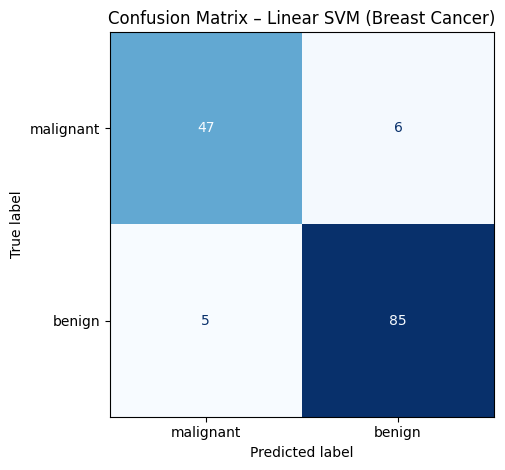

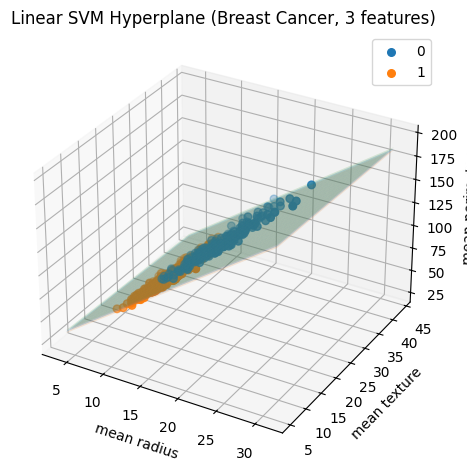

In [ ]:
def part1_linear_svm_3d():
    bc = datasets.load_breast_cancer()
    feat_idx = [0, 1, 2]
    X = bc.data[:, feat_idx]
    y = bc.target
    names = [bc.feature_names[i] for i in feat_idx]

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear"))
    ])

    params = {"svc__C": [0.01, 0.1, 1, 10, 100]}
    gs = GridSearchCV(pipe, params, cv=5, n_jobs=-1)
    gs.fit(Xtr, ytr)

    best = gs.best_estimator_
    ypred = best.predict(Xte)
    acc = accuracy_score(yte, ypred)

    print("\n=== Part 1: Linear SVM (Breast Cancer) ===")
    print("Best params:", gs.best_params_)
    print("Test accuracy:", f"{acc:.4f}")
    print("\nClassification report:\n", classification_report(yte, ypred, target_names=["malignant", "benign"], digits=4))

    plt.figure()
    ConfusionMatrixDisplay.from_predictions(yte, ypred, display_labels=["malignant", "benign"], cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix – Linear SVM (Breast Cancer)")
    plt.tight_layout()

    plot_linear_svm_3d(X, y, best, names, "Linear SVM Hyperplane (Breast Cancer, 3 features)")

part1_linear_svm_3d()
plt.show()

Non-Linear RBF SVM (Iris Binary)


=== Part 2: Non-Linear RBF SVM (Iris Binary) ===
Best params: {'svc__C': 10, 'svc__gamma': 1}
Test accuracy: 0.9600

Classification report:
               precision    recall  f1-score   support

  versicolor     0.9231    1.0000    0.9600        12
   virginica     1.0000    0.9231    0.9600        13

    accuracy                         0.9600        25
   macro avg     0.9615    0.9615    0.9600        25
weighted avg     0.9631    0.9600    0.9600        25



<Figure size 640x480 with 0 Axes>

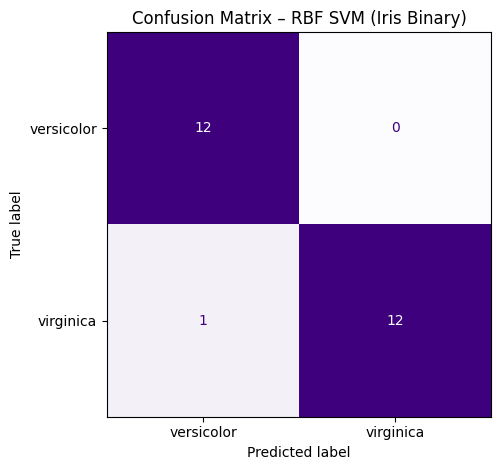

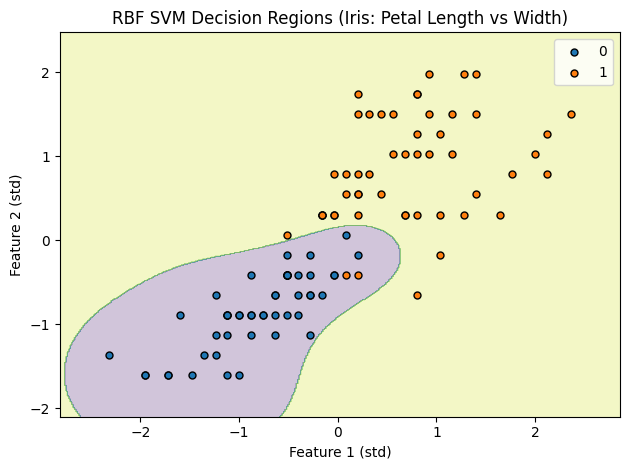

In [ ]:
def part2_nonlinear_svm_iris():
    iris = datasets.load_iris()
    mask = iris.target != 0
    X = iris.data[mask][:, 2:4]
    y = iris.target[mask]
    y = (y == 2).astype(int)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf"))
    ])

    params = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": ["scale", 0.1, 0.5, 1, 2]}
    gs = GridSearchCV(pipe, params, cv=5, n_jobs=-1)
    gs.fit(Xtr, ytr)

    best = gs.best_estimator_
    ypred = best.predict(Xte)
    acc = accuracy_score(yte, ypred)

    print("\n=== Part 2: Non-Linear RBF SVM (Iris Binary) ===")
    print("Best params:", gs.best_params_)
    print("Test accuracy:", f"{acc:.4f}")
    print("\nClassification report:\n", classification_report(yte, ypred, target_names=["versicolor", "virginica"], digits=4))

    plt.figure()
    ConfusionMatrixDisplay.from_predictions(yte, ypred, display_labels=["versicolor", "virginica"], cmap="Purples", colorbar=False)
    plt.title("Confusion Matrix – RBF SVM (Iris Binary)")
    plt.tight_layout()

    plot_rbf_decision_regions_2d(X, y, best, "RBF SVM Decision Regions (Iris: Petal Length vs Width)")

part2_nonlinear_svm_iris()
plt.show()

Multi-Feature SVM (Wine Dataset)


=== Part 3: Multi-Feature SVM (Wine, 3-class) ===
Best params: {'svc__C': 1, 'svc__gamma': 0.05}
Test accuracy: 0.9778

Classification report:
               precision    recall  f1-score   support

     class_0     1.0000    0.9333    0.9655        15
     class_1     0.9474    1.0000    0.9730        18
     class_2     1.0000    1.0000    1.0000        12

    accuracy                         0.9778        45
   macro avg     0.9825    0.9778    0.9795        45
weighted avg     0.9789    0.9778    0.9777        45



<Figure size 640x480 with 0 Axes>

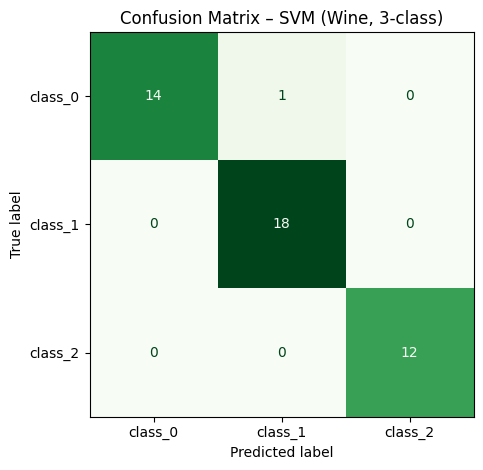

In [ ]:
def part3_multifeature_svm_wine():
    wine = datasets.load_wine()
    X = wine.data
    y = wine.target

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf"))
    ])

    params = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": ["scale", 0.05, 0.1, 0.5, 1]}
    gs = GridSearchCV(pipe, params, cv=5, n_jobs=-1)
    gs.fit(Xtr, ytr)

    best = gs.best_estimator_
    ypred = best.predict(Xte)
    acc = accuracy_score(yte, ypred)

    print("\n=== Part 3: Multi-Feature SVM (Wine, 3-class) ===")
    print("Best params:", gs.best_params_)
    print("Test accuracy:", f"{acc:.4f}")
    print("\nClassification report:\n", classification_report(yte, ypred, target_names=wine.target_names, digits=4))

    plt.figure()
    ConfusionMatrixDisplay.from_predictions(yte, ypred, display_labels=wine.target_names, cmap="Greens", colorbar=False)
    plt.title("Confusion Matrix – SVM (Wine, 3-class)")
    plt.tight_layout()

part3_multifeature_svm_wine()
plt.show()

SVR (Regression on Diabetes Da)


=== Part 4: SVR (Diabetes) ===
Best params: {'svr__C': 10, 'svr__epsilon': 0.05, 'svr__gamma': 0.1}
Test RMSE: 61.1817


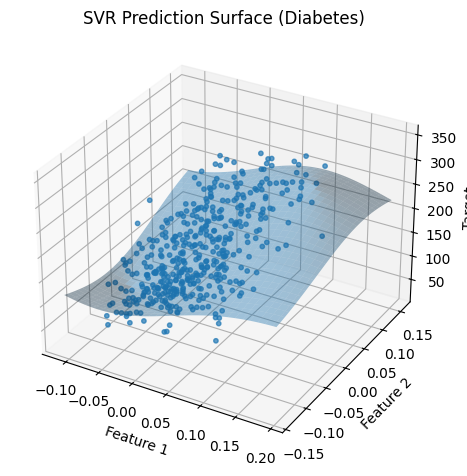

In [ ]:
def part4_svr_diabetes():
    # Part 4: SVR (Regression) – Diabetes, 3D Surface

    from sklearn.datasets import load_diabetes

    data = load_diabetes()
    X_all = data.data
    y = data.target

    # pick two real features for 3D plot (e.g., BMI and BP indices in this standardized dataset)
    feat_idx = [2, 3]
    X2 = X_all[:, feat_idx]

    Xtr, Xte, ytr, yte = train_test_split(X2, y, test_size=0.25, random_state=7)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ])

    params = {
        "svr__C": [1, 10, 50],
        "svr__gamma": ["scale", 0.1, 0.5],
        "svr__epsilon": [0.05, 0.1, 0.2]
    }

    gs = GridSearchCV(pipe, params, cv=3, n_jobs=-1)
    gs.fit(Xtr, ytr)

    best = gs.best_estimator_
    ypred = best.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, ypred))

    print("\n=== Part 4: SVR (Diabetes) ===")
    print("Best params:", gs.best_params_)
    print("Test RMSE:", f"{rmse:.4f}")

    plot_svr_surface_3d(X2, y, best, "SVR Prediction Surface (Diabetes)")

part4_svr_diabetes()
plt.show()